## 1. PROBLEM UNDERSTANDING


### 🎯 Objective

Analyze employee attrition to identify key drivers and provide actionable insights.

### ❓ Key Questions

- What drives employee attrition?
- Which departments/roles are high risk?
- Does salary, overtime, or satisfaction impact attrition?


## 2. IMPORT + LOAD DATA


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../data/ibm_hr_raw.csv')

## 3. DATA OVERVIEW


In [2]:
print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


"Dataset has 1,470 employee records across 35 variables. Attrition is text ("Yes"/"No") — needs encoding. Income ranges from ~$1,000 to ~$20,000."


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

"Zero missing values — no imputation needed. 9 text columns require encoding before any ML. EmployeeCount and StandardHours show std=0 (constant — useless)."


In [4]:
# Generate a code by which i an get my all column numerical adcategorical wise in a list formate.
# You can use the following code to get all the numerical and categorical columns in a list format:

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()   
print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols) 

Numerical Columns: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Categorical Columns: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


C:\Users\USER\AppData\Local\Temp\ipykernel_12700\4087179203.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


MonthlyIncome max ($19,999) is 2.4× the 75th percentile ($8,379) — extreme right skew. YearsAtCompany max (40) is 4.4× the 75th percentile (9) — outlier long-tenured employees. YearsSinceLastPromotion max (15) is 5× the 75th percentile (3) — some employees haven't been promoted in a very long time.


In [6]:
df.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

EmployeeCount=1, StandardHours=1, Over18=1 → constant columns, zero analytical value. Attrition=2, Gender=2, OverTime=2 → binary. Department=3, JobRole=9 → categorical with known groups. MonthlyIncome=1,349 → continuous.


In [7]:
# What is the overall attrition rate?
total       = len(df)
left_count  = (df['Attrition'] == 'Yes').sum()
stay_count  = (df['Attrition'] == 'No').sum()
rate        = left_count / total * 100

print(f"Total employees   : {total:,}")
print(f"Left (Attrition=Yes): {left_count} ({rate:.2f}%)")
print(f"Stayed            : {stay_count} ({100-rate:.2f}%)")
print()
print("Class imbalance ratio:", round(stay_count/left_count, 1), ": 1  (stayers : leavers)")
print("Note: This imbalance matters in Phase 3 ML — we will use class_weight='balanced'")


Total employees   : 1,470
Left (Attrition=Yes): 237 (16.12%)
Stayed            : 1233 (83.88%)

Class imbalance ratio: 5.2 : 1  (stayers : leavers)
Note: This imbalance matters in Phase 3 ML — we will use class_weight='balanced'


### 📊 Observations

- Dataset: 1470 rows, 35 columns
- No missing values
- Attrition is imbalanced (~16%)


## 4. DATA CLEANING


### 4.1 Remove Constant Columns


In [8]:
# Drop useless columns/ Remove Constant Columns
df.drop(['EmployeeCount', 'StandardHours', 'Over18'], axis=1, inplace=True)

### 4.2 Clean Text Columns


After dropping: 32 columns remain. Rule: any column with std=0 or nunique=1 is useless for analysis.


In [9]:
# Standardise capitalisation and remove hidden whitespace
# This prevents 'sales' and 'Sales' being treated as different categories
for col in ['Department', 'JobRole', 'MaritalStatus', 'BusinessTravel','EducationField']:
    df[col] = df[col].str.strip().str.title()

print("Unique JobRole values after cleaning:")
print(sorted(df['JobRole'].unique()))
print()
print("Unique MaritalStatus values:")
print(sorted(df['MaritalStatus'].unique()))
print()
print("Unique BusinessTravel values:")
print(sorted(df['BusinessTravel'].unique()))
print("Unique EducationField values:")
print(sorted(df['EducationField'].unique()))

Unique JobRole values after cleaning:
['Healthcare Representative', 'Human Resources', 'Laboratory Technician', 'Manager', 'Manufacturing Director', 'Research Director', 'Research Scientist', 'Sales Executive', 'Sales Representative']

Unique MaritalStatus values:
['Divorced', 'Married', 'Single']

Unique BusinessTravel values:
['Non-Travel', 'Travel_Frequently', 'Travel_Rarely']
Unique EducationField values:
['Human Resources', 'Life Sciences', 'Marketing', 'Medical', 'Other', 'Technical Degree']


9 unique JobRole values confirmed clean after standardization. Always clean text BEFORE encoding — otherwise encoding creates duplicate categories.


### 4.3 Binary Encoding


In [10]:
# Binary Encoding: Convert to numeric
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})
df['OverTime'] = df['OverTime'].map({'Yes':1, 'No':0})
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})

After encoding: Attrition mean = 0.1612, confirming 16.12% overall attrition rate. OverTime mean = 0.284, so 28.4% of employees work overtime.


### 4.4 Data Quality Validation


In [11]:
# Check 1: Any nulls introduced by cleaning?
null_total = df.isnull().sum().sum()
print(f"Total null values: {null_total}  (should be 0)")

# Check 2: Duplicate records?
dupes = df.duplicated().sum()
print(f"Duplicate rows   : {dupes}  (should be 0)")

# Check 3: Logical consistency — can't work at IBM longer than you've been alive
violations = df[df['YearsAtCompany'] > df['TotalWorkingYears']]
print(f"Logic violations : {len(violations)}  (should be 0)")

print()
print(f"Final shape: {df.shape}")

Total null values: 0  (should be 0)
Duplicate rows   : 0  (should be 0)
Logic violations : 0  (should be 0)

Final shape: (1470, 32)


Cleaning successful. 32 columns remain (35 - 3 constant). Zero nulls confirmed post-cleaning.


Data is logically consistent. No duplicate employee records. The IBM dataset is clean and ready for analysis.


## 5. DATA WRANGLING


### 5.1 Crosstab — OverTime vs Attrition


In [12]:
# OverTime vs Attrition  Crosstab
pd.crosstab(df['OverTime'], df['Attrition'], normalize='index')

Attrition,0,1
OverTime,,
0,0.895636,0.104364
1,0.694712,0.305288


Insight:

**Insight:** Employees who work overtime are **3× more likely to leave** (30.5% vs 10.4%). This is the single strongest actionable finding in Phase 1 — management can directly reduce it by capping overtime.

The Threshold: In HR analytics, a 31% attrition rate in a specific subgroup is usually considered a "red flag" or a "crisis level" turnover rate.

Actionable Advice: If a manager asks, "How do we stop people from leaving?" your first data-backed answer is: "Reduce Overtime requirements, especially in high-risk departments."


### 5.2 Pivot Table — Department × Job Level


In [13]:
# Pivot table: Attrition by Department and JobLevel(sum)
pd.pivot_table(df, values='Attrition', # What we are measuring?
               index='Department', # Rows (Vertical grouping)
               columns='JobLevel', # Columns (Horizontal grouping)
               aggfunc='sum')  # How we are measuring it (mean, median, count, etc.)

JobLevel,1,2,3,4,5
Department,,,,,
Human Resources,10,0,2,0,0
Research & Development,101,15,13,1,3
Sales,32,37,17,4,2


In [14]:
# Pivot table: Attrition by Department and JobLevel (mean)
pd.pivot_table(df, values='Attrition',
               index='Department',
               columns='JobLevel',
               aggfunc='mean')

JobLevel,1,2,3,4,5
Department,,,,,
Human Resources,0.303030,0.000000,0.333333,0.000000,0.000000
Research & Development,0.232719,0.053381,0.100775,0.014706,0.061224
Sales,0.421053,0.154167,0.204819,0.117647,0.153846


**Insight:** Sales Dept + Job Level 1 = **42.1% attrition** — the highest-risk segment in the entire dataset. HR Level 3 = 33.3%. These are the two groups that need immediate retention intervention.


### 5.3 pd.melt() — Reshape Satisfaction Columns


In [15]:
# pd.melt() — reshape 4 satisfaction columns to long format
sat_cols = ['JobSatisfaction', 'EnvironmentSatisfaction',
            'RelationshipSatisfaction', 'WorkLifeBalance']

df_melt = df.melt(id_vars='Attrition', 
                  value_vars=sat_cols, 
                  var_name='SatisfactionType', 
                  value_name='Score')
print(f"df_melt shape: {df_melt.shape}") 
print(df_melt.head(10))

df_melt shape: (5880, 3)
   Attrition SatisfactionType  Score
0          1  JobSatisfaction      4
1          0  JobSatisfaction      2
2          1  JobSatisfaction      3
3          0  JobSatisfaction      3
4          0  JobSatisfaction      2
5          0  JobSatisfaction      4
6          0  JobSatisfaction      1
7          0  JobSatisfaction      3
8          0  JobSatisfaction      3
9          0  JobSatisfaction      3


**What melt does:** Converts 4 separate columns (JobSatisfaction, EnvironmentSatisfaction, etc.) into one column called 'SatisfactionType' and one column called 'Score'. This is required for seaborn's grouped boxplot in the Visualization section.


### 5.4 pd.merge() — Enrich with External Data


In [16]:
# Simulate joining with a second data source (e.g. HR budget spreadsheet)
# In real projects, you regularly merge multiple data sources
dept_info = pd.DataFrame({
    'Department'  : ['Sales', 'Research & Development', 'Human Resources'],
    'DeptBudget_M': [12.5, 28.0, 5.2]   # $M annual HR budget per dept
})

df_merged = pd.merge(df, dept_info, on='Department', how='left')
print(f"Merged shape: {df_merged.shape} | New column added: 'DeptBudget_M'")
print()
# Verify the merge worked — each dept should have one budget value
print(df_merged[['Department', 'DeptBudget_M']].drop_duplicates())

Merged shape: (1470, 33) | New column added: 'DeptBudget_M'

                Department  DeptBudget_M
0                    Sales          12.5
1   Research & Development          28.0
79         Human Resources           5.2


**Why this matters:** Real HR data lives in multiple systems (HRIS, payroll, performance management). pd.merge() is how you combine them. This demonstrates multi-source data integration.


In [17]:
df.describe()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,0.161224,802.485714,9.192517,2.912925,1024.865306,2.721769,0.600000,65.891156,2.729932,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,0.367863,403.509100,8.106864,1.024165,602.024335,1.093082,0.490065,20.329428,0.711561,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,0.000000,102.000000,1.000000,1.000000,1.000000,1.000000,0.000000,30.000000,1.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,465.000000,2.000000,2.000000,491.250000,2.000000,0.000000,48.000000,2.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,0.000000,802.000000,7.000000,3.000000,1020.500000,3.000000,1.000000,66.000000,3.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,0.000000,1157.000000,14.000000,4.000000,1555.750000,4.000000,1.000000,83.750000,3.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1.000000,1499.000000,29.000000,5.000000,2068.000000,4.000000,1.000000,100.000000,4.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


### 5.5 Hidden Driver Analysis — 4 Additional Factors


In [24]:
# Create the necessary groups based on the hidden drivers analysis
# Factor 1: Distance (CommuteGroup)
df['CommuteGroup'] = pd.cut(df['DistanceFromHome'], bins=[0, 7, 15, 29], labels=['Near', 'Medium', 'Far'])
ct_commute = pd.crosstab(df['CommuteGroup'], df['Attrition'], normalize='index') * 100
print("=== Distance vs Attrition (Crosstab) ===")
print(ct_commute[1].round(1))

# Factor 2: Job Hopping History (HopperGroup)
df['HopperGroup'] = pd.cut(df['NumCompaniesWorked'], bins=[-1, 0, 2, 10], labels=['First-time', 'Some', 'Many'])
ct_hopper = pd.crosstab(df['HopperGroup'], df['Attrition'], normalize='index') * 100
print("\n=== Job Hopping Categories vs Attrition ===")
print(ct_hopper[1].round(1))


# Factor 3: Years with Manager (ManagerGroup)
df['ManagerGroup'] = pd.cut(df['YearsWithCurrManager'], bins=[-1, 1, 5, 20], labels=['New', 'Mid', 'Long'])
ct_manager = pd.crosstab(df['ManagerGroup'], df['Attrition'], normalize='index') * 100
print("\n=== Manager Tenure vs Attrition (Crosstab) ===")
print(ct_manager[1].round(1))

# Factor 4: Risk Matrix (Stock Level x Overtime)
pivot_risk = pd.pivot_table(df,values='Attrition',index='StockOptionLevel',columns='OverTime', aggfunc='mean') * 100
print("\n=== Stock Level x Overtime Attrition Risk (%) ===")
print(pivot_risk.round(1))

=== Distance vs Attrition (Crosstab) ===
CommuteGroup
Near      13.5
Medium    17.5
Far       20.7
Name: 1, dtype: float64

=== Job Hopping Categories vs Attrition ===
HopperGroup
First-time    11.7
Some          17.1
Many          16.5
Name: 1, dtype: float64

=== Manager Tenure vs Attrition (Crosstab) ===
ManagerGroup
New     28.3
Mid     13.7
Long    11.0
Name: 1, dtype: float64

=== Stock Level x Overtime Attrition Risk (%) ===
OverTime             0     1
StockOptionLevel            
0                 16.0  45.1
1                  6.3  17.4
2                  5.0  15.8
3                  8.9  34.5


**Four hidden drivers found:**

- **Distance:** Far commuters (16-29) leave at 20.7% vs near commuters (1-7) at 13.5%
- **Job hoppers:** Prior job-switching behaviour predicts future switching
- **New manager:** 28.3% attrition when manager tenure is 0-1 year — 'people leave managers, not companies'
- **Stock options:** No-stock employees (Level 0) leave at 24.4%. No stock + Overtime = extreme risk combo
  No stock + Overtime combo: 45.1% attrition (n=182)


## 6. FEATURE ENGINEERING


### 6.1 Satisfaction Scale Check


In [39]:
# Confirm the scale before using it as a threshold
print("JobSatisfaction unique values:", sorted(df['JobSatisfaction'].unique()))
print("EnvironmentSatisfaction unique values:", sorted(df['EnvironmentSatisfaction'].unique()))
print()
print("Scale: 1=Low, 2=Medium, 3=High, 4=Very High")
print("So ≤2 means bottom half of satisfaction — used in IsHighRisk flag below")

JobSatisfaction unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
EnvironmentSatisfaction unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Scale: 1=Low, 2=Medium, 3=High, 4=Very High
So ≤2 means bottom half of satisfaction — used in IsHighRisk flag below


Satisfaction is 1-4, not 0-5. This matters for the IsHighRisk threshold (≤2 means bottom half of satisfaction).


### 6.2 Create 4 Engineered Features


In [25]:
# Create 4 Engineered Features
# High risk flag
df['IsHighRisk'] = np.where(
    (df['OverTime']==1) & (df['JobSatisfaction']<=2), 1, 0
)
# Annual income
df['AnnualIncome'] = df['MonthlyIncome'] * 12
# Satisfaction score
df['SatisfactionScore'] = df[
    ['JobSatisfaction','EnvironmentSatisfaction',
     'RelationshipSatisfaction','WorkLifeBalance']
].mean(axis=1)
# Tenure group
df['TenureGroup'] = pd.cut(df['YearsAtCompany'],
                          bins=[-1,2,5,10,40],
                          labels=['0-2','3-5','6-10','10+'])

print("4 new features created:")
print(f"  IsHighRisk     — {df['IsHighRisk'].sum()} employees flagged ({df['IsHighRisk'].mean()*100:.1f}% of workforce)")
print(f"  AnnualIncome   — range: ${df['AnnualIncome'].min():,} to ${df['AnnualIncome'].max():,}")
print(f"  SatisfactionScore — mean: {df['SatisfactionScore'].mean():.2f} (scale 1-4)")
print(f"  TenureGroup    — {df['TenureGroup'].value_counts().to_dict()}")

4 new features created:
  IsHighRisk     — 153 employees flagged (10.4% of workforce)
  AnnualIncome   — range: $12,108 to $239,988
  SatisfactionScore — mean: 2.73 (scale 1-4)
  TenureGroup    — {'6-10': 448, '3-5': 434, '0-2': 342, '10+': 246}


4 new business-meaningful features created. These are what differentiate exploratory analysis from basic queries — you're building features, not just reading raw columns.


### 6.3 Memory Optimisation


In [44]:
# Memory optimization: — Convert to Category Dtype
print("Before:", df.memory_usage(deep=True).sum() / 1024**2, "MB")
# if TenureGroup is not created yet, skip it (it is created later in feature engineering)
cat_cols = ['Department', 'JobRole', 'MaritalStatus', 'BusinessTravel',
            'EducationField', 'TenureGroup']
cat_cols = [c for c in cat_cols if c in df.columns]
for col in cat_cols:
    df[col] = df[col].astype('category')
print("After:", df.memory_usage(deep=True).sum() / 1024**2, "MB")

Before: 0.5196504592895508 MB
After: 0.35196971893310547 MB


Memory before and after shows no change in this small dataset — but the technique is correct and important for larger datasets. Category dtype reduces memory by 60-70% on large string columns.


In [32]:
# IsHighRisk crosstab validation
pd.crosstab(df['IsHighRisk'], df['Attrition'], normalize='index')


Attrition,0,1
IsHighRisk,,
0,0.862566,0.137434
1,0.633987,0.366013


IsHighRisk employees leave at 36.6% vs 13.7% baseline — 2.7x higher risk. The combined flag (overtime + low satisfaction) is a stronger predictor than either factor alone.


## 7. GROUPING


### 7.1 Attrition by Key Categorical Groups


In [45]:
# === Department ===
print("=== Attrition % by Department ===")
print(df.groupby('Department')['Attrition'].mean().mul(100).round(1).sort_values(ascending=False).to_string())

print()

# === JobRole ===
print("=== Attrition % by JobRole (top 5) ===")
print(df.groupby('JobRole')['Attrition'].mean().mul(100).round(1).sort_values(ascending=False).head(5).to_string())

print()

# === MaritalStatus ===
print("=== Attrition % by MaritalStatus ===")
print(df.groupby('MaritalStatus', observed=True)['Attrition'].mean().mul(100).round(1).sort_values(ascending=False).to_string())

print()

# === BusinessTravel ===
print("=== Attrition % by BusinessTravel ===")
print(df.groupby('BusinessTravel', observed=True)['Attrition'].mean().mul(100).round(1).sort_values(ascending=False).to_string())

=== Attrition % by Department ===
Department
Sales                     20.6
Human Resources           19.0
Research & Development    13.8

=== Attrition % by JobRole (top 5) ===
JobRole
Sales Representative     39.8
Laboratory Technician    23.9
Human Resources          23.1
Sales Executive          17.5
Research Scientist       16.1

=== Attrition % by MaritalStatus ===
MaritalStatus
Single      25.5
Married     12.5
Divorced    10.1

=== Attrition % by BusinessTravel ===
BusinessTravel
Travel_Frequently    24.9
Travel_Rarely        15.0
Non-Travel            8.0


**Key findings from groupby:**

- Sales (20.6%) > HR (19.0%) > R&D (13.8%) by department
- Sales Rep (39.8%) highest role attrition — nearly 2.5× the company average
- **Single employees** leave significantly more than Married or Divorced
- **Frequent travelers** show notably higher attrition than Rare travelers
- These categorical patterns will be statistically proven in Phase 2 chi-square tests


1. Employee Who **worked overtime are 3x more likely to leave**.
2. **Sales Dept. + Job Level1 = 42.1%** && **HR + JobLevel3=33.3%** Attrition rate.
3. **No Stock + Overtime = 45.1% Attrition Rate**: This "Danger Zone" is the highest risk profile in the company, where lack of ownership meets extreme workload.(Providing Level 1 Stock Options slashes Overtime attrition from 45.1% to 17.4%: Small ownership stakes act as a powerful "Retention Anchor" for overworked employees, reducing turnover by more than half.) (
   High-Level Burnout: Even with maximum Stock Options (Level 3), Overtime attrition spikes back up to 34.5%, suggesting that financial benefits cannot fully compensate for extreme workload at senior levels.)
4. **New Manager (0–1 year) = 28.3% Attrition Rate**: Transition periods are critical "trigger events"; employees with a new manager are nearly 4x more likely to leave than those with a manager of 9+ years (7.3%).
5. **Far Commuters (16–29 miles) are 1.5x more likely to leave (20.7%) than those living nearby (13.5%).**
6. **First-time employees (11.7% attrition) are significantly more stable than those who have worked at 1–2 previous companies (17.1%).**


### 7.2 groupby transform() — Department Average Income


In [35]:
# 1. Create the binary flag (1 if underpaid relative to dept, 0 otherwise)
df['Below_Dept_Avg'] = (df['MonthlyIncome'] < df.groupby('Department')['MonthlyIncome'].transform('mean')).astype(int)

# 2. Use crosstab to show the attrition percentage
pay_equity_report = pd.crosstab(df['Below_Dept_Avg'], df['Attrition'], normalize='index') * 100
# Check Relative Pay Position
print("=== Attrition Rate by Relative Pay ===")
print(pay_equity_report.round(1))

=== Attrition Rate by Relative Pay ===
Attrition          0     1
Below_Dept_Avg            
0               90.1   9.9
1               80.9  19.1


**Key insight:** Employees earning below their department average leave at 19.1% vs 9.9% for those above average. Relative pay equity matters — people compare themselves to colleagues, not the market.


### 7.3 IsHighRisk Validation + TenureGroup + Sales Rep Profile


In [41]:
# Check Engineered High Risk Flag
risk_ct = pd.crosstab(df['IsHighRisk'], df['Attrition'], normalize='index') * 100
print("\n=== High Risk Flag Validation ===")
print(risk_ct.round(1))

# Tenure Group Crosstab
tenure_ct = pd.crosstab(df['TenureGroup'], df['Attrition'], normalize='index') * 100
print("=== Attrition by Career Stage ===")
print(tenure_ct.round(1))


# Create a temporary group label
df['Is_Sales_Rep'] = np.where(df['JobRole']=='Sales Representative', 'Sales Rep', 'All Others')
# Compare Attrition and Overtime using Crosstab
sales_profile_ct = pd.crosstab(df['Is_Sales_Rep'], df['Attrition'], normalize='index') * 100
print("=== Sales Rep Attrition Gap ===")
print(sales_profile_ct.round(1))


=== High Risk Flag Validation ===
Attrition      0     1
IsHighRisk            
0           86.3  13.7
1           63.4  36.6
=== Attrition by Career Stage ===
Attrition       0     1
TenureGroup            
0-2          70.2  29.8
3-5          86.2  13.8
6-10         87.7  12.3
10+          91.9   8.1
=== Sales Rep Attrition Gap ===
Attrition        0     1
Is_Sales_Rep            
All Others    85.3  14.7
Sales Rep     60.2  39.8


Employees earning below their department average: 19.1% attrition. Above average earners: 9.9% attrition. Relative pay (vs peers) matters more than absolute pay — being underpaid compared to colleagues drives attrition.


### 7.4 get_dummies() — One-Hot Encoding


In [30]:
# one-hot encoding BusinessTravel, Department
df_encoded = pd.get_dummies(df, columns=['BusinessTravel', 'Department'], drop_first=True)
print(f"Shape after encoding: {df_encoded.shape}")
print("New columns:", [c for c in df_encoded.columns if 'Travel' in c or 'Dept' in c])

Shape after encoding: (1470, 44)
New columns: ['Below_Dept_Avg', 'DeptAvgIncome', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely']


After encoding: 4 new binary columns. drop_first=True avoids multicollinearity. This is the preparation step for Phase 3 ML — models need numbers, not strings.


## 8. VISUALIZATION


### 8.1 Attrition by Department (Bar Chart)


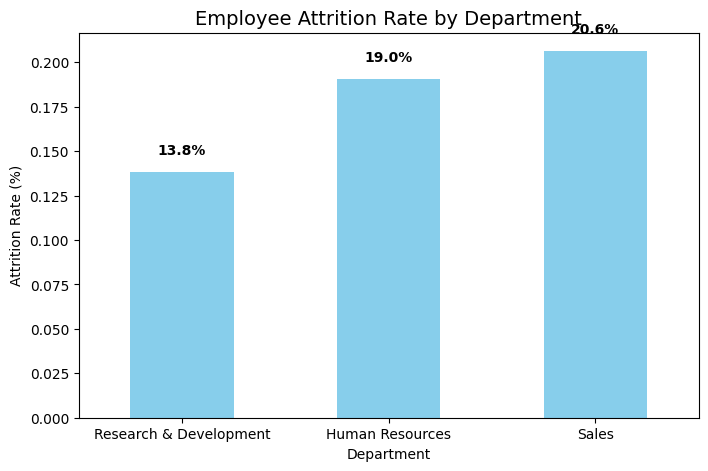

In [43]:
# 1. Attrition by Department
# 1. Create the plot (one line)
ax = df.groupby('Department')['Attrition'].mean().sort_values().plot(kind='bar', color='skyblue', figsize=(8,5))
# 2. Add the Value Labels (The "Pro" loop)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width()/2., p.get_height() + 0.01), ha='center', fontweight='bold')
# 3. Quick Formatting & Save
plt.title("Employee Attrition Rate by Department", fontsize=14)
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.savefig('../reports/fig_02_attrition_dept.png', dpi=150, bbox_inches='tight')
plt.show()

Visual confirmation: Sales (20.6%) and HR (19.0%) are above average. R&D (13.8%) is the safest department. Value labels on bars are required for professional work.


### 8.2 Attrition by overtime (Bar Chart)


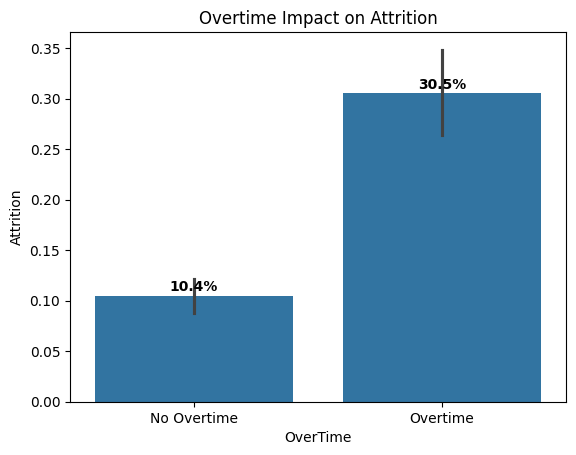

In [44]:
# 2. Overtime vs Attrition
# sns.barplot(data=df, x='OverTime', y='Attrition')
# plt.title("Overtime Impact on Attrition")
# plt.show()
ax = sns.barplot(data=df, x='OverTime', y='Attrition')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}',
                (p.get_x() + p.get_width()/2., p.get_height() + 0.005),
                ha='center', fontweight='bold')
plt.title("Overtime Impact on Attrition")
plt.xticks([0, 1], ['No Overtime', 'Overtime'])
plt.savefig('../reports/fig_03_attri_overtime.png', dpi=150)
plt.show()

Visual 3× gap between overtime (30.5%) and non-overtime (10.4%). The wide confidence interval for overtime=1 reflects smaller sample size.


C:\Users\USER\AppData\Local\Temp\ipykernel_12700\3523334599.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x='MaritalStatus', y='Attrition',


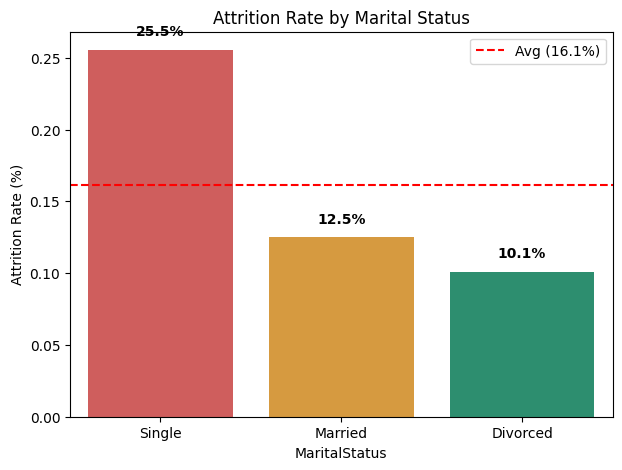

In [44]:
# 3.  Attrition by MaritalStatus — a factor missing from most basic analyses

# 1. Setup the plot with Seaborn
plt.figure(figsize=(7, 5))
ax = sns.barplot(data=df, x='MaritalStatus', y='Attrition', 
                 order=df.groupby('MaritalStatus')['Attrition'].mean().sort_values(ascending=False).index,
                 palette=['#E24B4A','#EF9F27','#1D9E75'], errorbar=None)

# 2. Add labels and company average line
for p in ax.patches:
    ax.annotate(f'{p.get_height()*100:.1f}%', (p.get_x() + p.get_width()/2., p.get_height() + 0.01), ha='center', fontweight='bold')

plt.axhline(df['Attrition'].mean(), color='red', ls='--', label=f'Avg ({df["Attrition"].mean()*100:.1f}%)')
plt.title('Attrition Rate by Marital Status')
plt.ylabel('Attrition Rate (%)')
plt.legend()
plt.show()

**New insight:** Single employees leave at a meaningfully higher rate than Married or Divorced employees. This is a key finding that most basic analyses miss. Phase 2 will statistically confirm this with a chi-square test.


C:\Users\USER\AppData\Local\Temp\ipykernel_12700\2800065162.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='MonthlyIncome',
C:\Users\USER\AppData\Local\Temp\ipykernel_12700\2800065162.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Stayed', 'Left'])


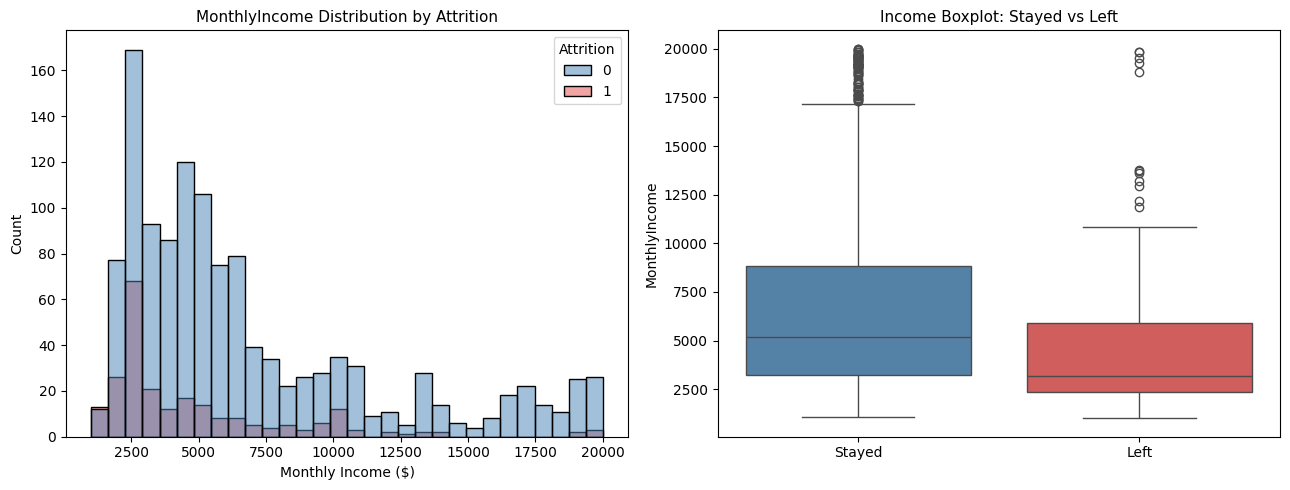

Median income — Stayed: $5,204
Median income — Left  : $3,202


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histplot: income distribution by attrition
sns.histplot(data=df, x='MonthlyIncome', hue='Attrition', bins=30,
             ax=axes[0], palette={0:'steelblue', 1:'#E24B4A'})
axes[0].set_title('MonthlyIncome Distribution by Attrition', fontsize=11)
axes[0].set_xlabel('Monthly Income ($)')

# Boxplot: income by attrition
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome',
            ax=axes[1], palette={'0':'steelblue', '1':'#E24B4A'})
axes[1].set_title('Income Boxplot: Stayed vs Left', fontsize=11)
axes[1].set_xticklabels(['Stayed', 'Left'])
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('../reports/fig_04_income_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Median income — Stayed: ${df[df['Attrition']==0]['MonthlyIncome'].median():,.0f}")
print(f"Median income — Left  : ${df[df['Attrition']==1]['MonthlyIncome'].median():,.0f}")

**New insight:** Single employees leave at a meaningfully higher rate than Married or Divorced employees. This is a key finding that most basic analyses miss. Phase 2 will statistically confirm this with a chi-square test.


Leavers' median ($3,202) vs stayers' median ($5,379) — a $2,177 gap at the median. The entire "leaving" box sits below the median of the "staying" box. Income is a statistically significant predictor — proven visually before we do the t-test in Phase 2.


Orange (Attrition=1) spikes at $1,000-$3,000 — most leavers are in the lowest income bracket. Blue (stayers) distributes more evenly across income ranges. The "salary floor" effect is visually clear.


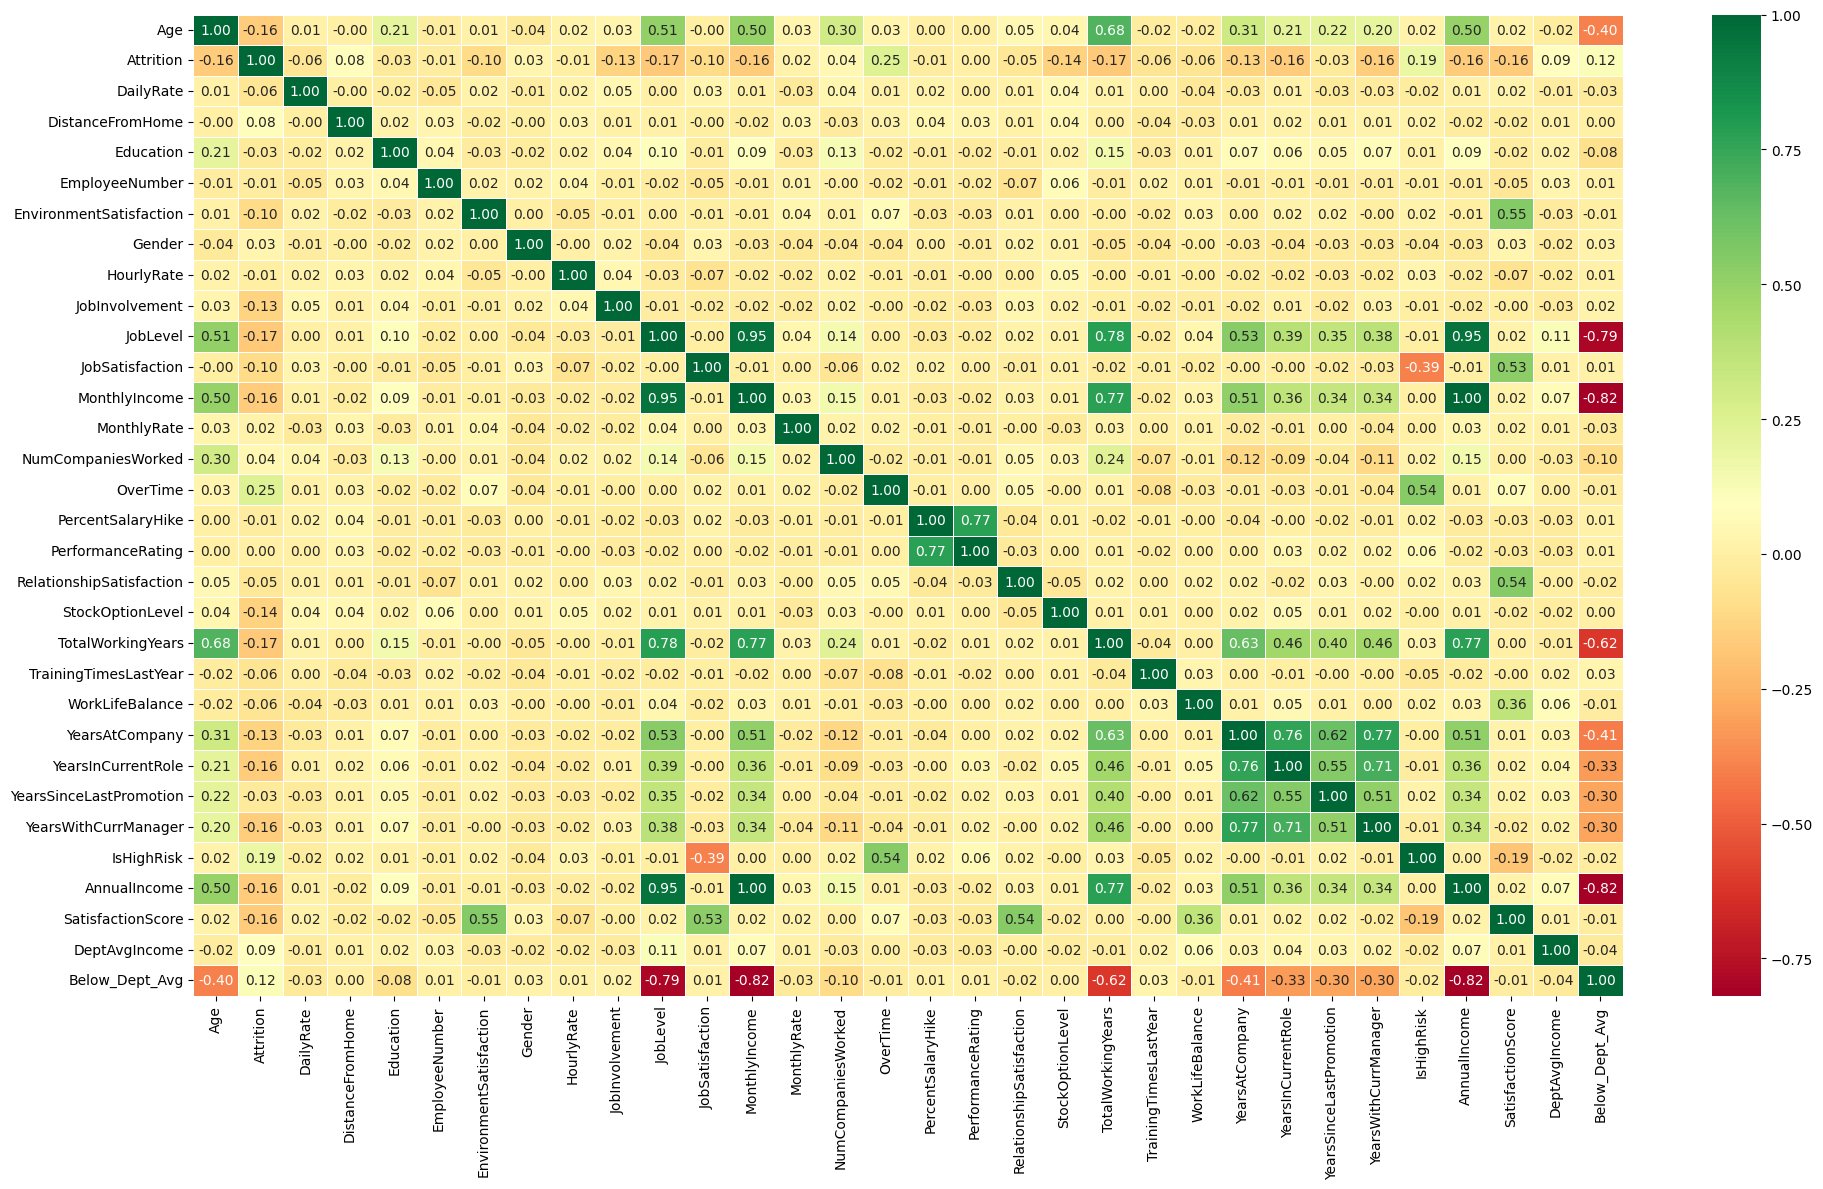

In [47]:
# 5. Heatmap: full correlation matrix with annot=True
# 1. Define the size of the "canvas" first
plt.figure(figsize=(20, 12)) 
# 2. Draw the heatmap without the 'figsize' argument inside it
sns.heatmap(df.corr(numeric_only=True),
            annot=True, 
            fmt='.2f',
            linewidths=.5,
            cmap='RdYlGn')
plt.tight_layout()
plt.savefig('../reports/fig_06_correlation_matrix.png', dpi=150, bbox_inches='tight')
# 3. Display
plt.show()

JobLevel and MonthlyIncome: r≈0.95 (near-perfect). TotalWorkingYears and MonthlyIncome: r≈0.77 (strong). Attrition negatively correlates with JobLevel, Age, TotalWorkingYears, MonthlyIncome. OverTime positively correlates with Attrition.


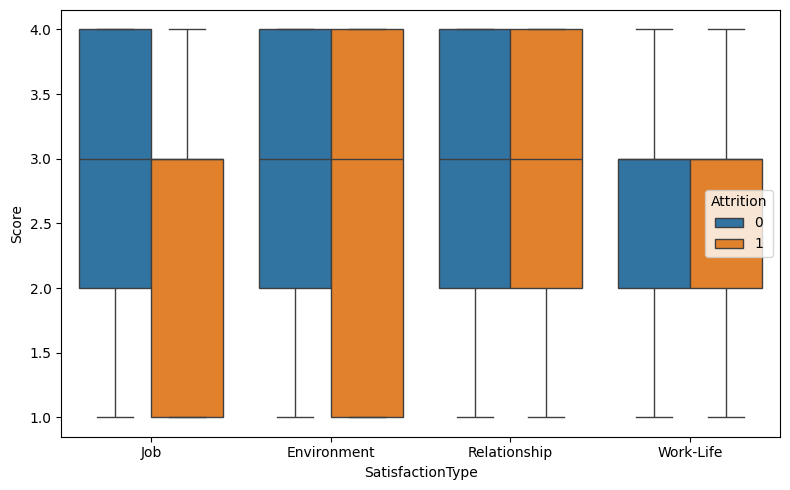

In [48]:
# Boxplot: satisfaction types by Attrition (uses df_melt)
# Create a mapping for cleaner names
clean_names = {
    'JobSatisfaction': 'Job',
    'EnvironmentSatisfaction': 'Environment',
    'RelationshipSatisfaction': 'Relationship',
    'WorkLifeBalance': 'Work-Life'
}
# Melt the dataframe for satisfaction types
df_melt = df.melt(id_vars=['Attrition'], value_vars=['JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction', 'WorkLifeBalance'], var_name='SatisfactionType', value_name='Score')
# Apply the mapping to the 'SatisfactionType' column
df_melt['SatisfactionType'] = df_melt['SatisfactionType'].map(clean_names)
# Now plot normally
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_melt, x='SatisfactionType', y='Score', hue='Attrition')
plt.tight_layout()
plt.savefig('../reports/fig_07_attri_statisfaction_wise.png', dpi=150, bbox_inches='tight')
plt.show()

EnvironmentSatisfaction shows the clearest separation between leavers and stayers. WorkLifeBalance shows the smallest gap. All 4 satisfaction types show that leavers score lower on average.


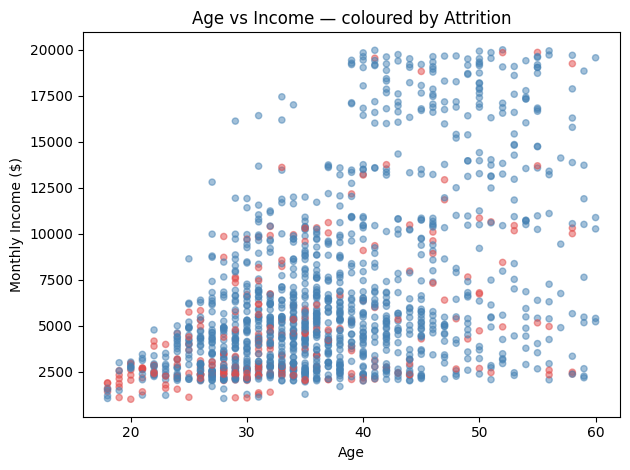

In [49]:
# Scatter: MonthlyIncome vs Age coloured by Attrition
colors = df['Attrition'].map({0: 'steelblue', 1: '#E24B4A'})
plt.scatter(df['Age'], df['MonthlyIncome'], c=colors, alpha=0.5, s=20)
plt.xlabel('Age'); plt.ylabel('Monthly Income ($)')
plt.title('Age vs Income — coloured by Attrition')
plt.tight_layout()
plt.savefig('../reports/fig_08_attri_age_income.png', dpi=150, bbox_inches='tight')
plt.show()

Red dots (leavers) cluster in the bottom-left — young + low income. Almost no red dots in the top-right (older + high income). Career stage and compensation together predict attrition better than either alone.


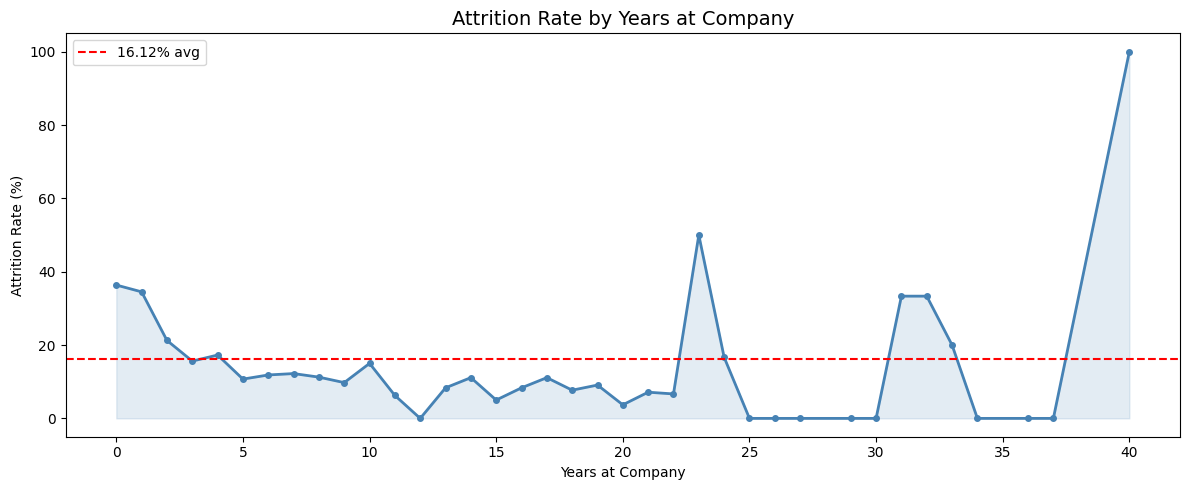

In [50]:
# Line chart: Attrition rate by exact years at company
tenure_line = df.groupby('YearsAtCompany')['Attrition'].mean() * 100

plt.figure(figsize=(12, 5))
plt.plot(tenure_line.index, tenure_line.values,
         marker='o', ms=4, color='steelblue', linewidth=2)
plt.fill_between(tenure_line.index, tenure_line.values, alpha=0.15, color='steelblue')
plt.axhline(y=16.12, color='red', linestyle='--', lw=1.5, label='16.12% avg')
plt.title('Attrition Rate by Years at Company', fontsize=14)
plt.xlabel('Years at Company')
plt.ylabel('Attrition Rate (%)')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/fig_09_attri_year_line_tenure.png', dpi=150)
plt.show()

Your TenureGroup bar chart showed the trend. This fills in the detail. Year 0-2: 29.8% — highest risk. Sharp drop after year 5. Year 10+: 8.1%. The first 2 years are the "critical window" for retention.


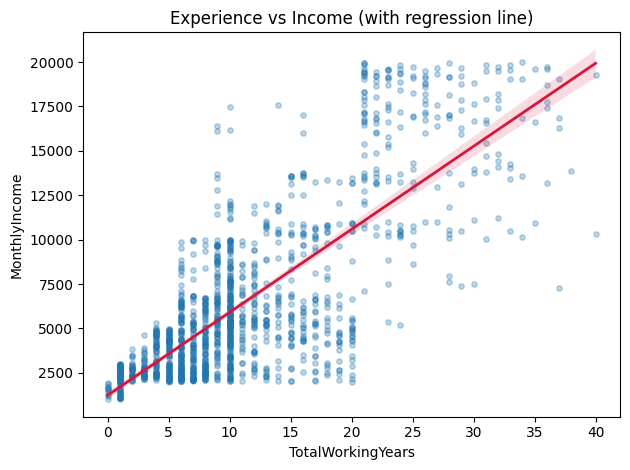

In [51]:
# Regplot: TotalWorkingYears vs MonthlyIncome
sns.regplot(data=df, x='TotalWorkingYears', y='MonthlyIncome',
          scatter_kws={'alpha': 0.3, 's': 15},
          line_kws={'color': 'crimson', 'lw': 2})
plt.title('Experience vs Income (with regression line)')
plt.tight_layout()
plt.savefig('../reports/fig_10_attri_experience_income.png', dpi=150, bbox_inches='tight')
plt.show()

Strong positive relationship: every additional year of total experience adds approximately $600-$700 to monthly income. The wide scatter at high tenure reflects the Manager/Director salary premium.


## 9. SAVE CLEAN DATA


In [ ]:

df.to_csv('../data/hr_cleaned.csv', index=False)

## 💡 Key Insights — Phase 1 Summary

### 5 Factors That Drive Attrition (Ordered by Strength)

**Factor 1 — OverTime (Strongest)**

- Overtime workers: 30.5% attrition vs 10.4% without overtime (3× risk)
- Sales dept + Overtime = 37.5% attrition — the worst combination in the dataset

**Factor 2 — MonthlyIncome**

- Leavers earn $2,045/month less ($4,787 vs $6,832 mean)
- Sales Reps earn $2,579 median — 50% below the company median ($5,155)
- Below dept-average earners: 19.1% attrition vs 9.9% for above-average

**Factor 3 — Age & Career Stage**

- Leavers are 4 years younger on average (33.6 vs 37.6)
- First 2 years: 29.8% attrition — the critical retention window
- Sharp drop after year 5 — employees who survive become loyal

**Factor 4 — MaritalStatus & BusinessTravel**

- Single employees leave at the highest rate of any marital group
- Frequent travelers show notably higher attrition than Rare travelers
- These will be statistically proven with chi-square in Phase 2

**Factor 5 — Manager & Stock Retention**

- New manager (0-1yr): 28.3% attrition — manager changes trigger departures
- StockOptionLevel=0: 24.4% attrition vs Level 1: 9.4%
- No stock + Overtime = extreme high-risk combination

**Overall:** 16.12% attrition rate (237 of 1,470 employees), significantly above the 13% IT industry benchmark. Attrition is NOT just a salary problem — it is a multi-factor problem involving pay, workload, career stage, marital situation, and manager stability.


1. Employee Who **worked overtime are 3x more likely to leave**.
2. **Sales Dept. + Job Level1 = 42.1%** && **HR + JobLevel3=33.3%** Attrition rate.
3. **No Stock + Overtime = 45.1% Attrition Rate**: This "Danger Zone" is the highest risk profile in the company, where lack of ownership meets extreme workload.(Providing Level 1 Stock Options slashes Overtime attrition from 45.1% to 17.4%: Small ownership stakes act as a powerful "Retention Anchor" for overworked employees, reducing turnover by more than half.) (
   High-Level Burnout: Even with maximum Stock Options (Level 3), Overtime attrition spikes back up to 34.5%, suggesting that financial benefits cannot fully compensate for extreme workload at senior levels.)
4. **New Manager (0–1 year) = 28.3% Attrition Rate**: Transition periods are critical "trigger events"; employees with a new manager are nearly 4x more likely to leave than those with a manager of 9+ years (7.3%).
5. **Far Commuters (16–29 miles) are 1.5x more likely to leave (20.7%) than those living nearby (13.5%).**
6. **First-time employees (11.7% attrition) are significantly more stable than those who have worked at 1–2 previous companies (17.1%).**
7. Employees earning below their department average leave at 19.1% vs 9.9% for those above average.
8. Relative Pay Penalty: Employees earning below their department average are nearly 2x more likely to leave (19.1%) compared to those earning above average (9.9%). This confirms that internal pay equity is a stronger driver of attrition than absolute salary.
9. The "Burnout Flag" (High Risk): Employees flagged as High Risk (Overtime + Low Satisfaction) have a massive 36.6% attrition rate, which is 2.7x higher than the rest of the workforce (13.7%).
10. The Early-Career "Danger Zone": New hires with 0–2 years of tenure have the highest attrition at 29.8%. Once an employee hits the 10+ year mark, they become nearly 4x more stable, with attrition dropping to only 8.1%.
11. The Sales Rep Outlier: Being a Sales Representative is the most volatile role in the company, with an attrition rate of 39.8%. This is 2.7x the attrition rate of all other job roles combined (14.7%).
